In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, applications
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing import image

In [ ]:
dataset_path = r"D:\Btech Resources\SEM6\dataset\dataset"

In [ ]:
batch_size = 32
img_size = (256, 256)

In [ ]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path, validation_split=0.2, subset="training", seed=42, image_size=img_size, batch_size=batch_size)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path, validation_split=0.2, subset="validation", seed=42, image_size=img_size, batch_size=batch_size)


Found 472 files belonging to 3 classes.
Using 378 files for training.


Found 472 files belonging to 3 classes.
Using 94 files for validation.


In [ ]:
class_names = train_ds.class_names
print(f"Classes: {class_names}")


Classes: ['Bacterial leaf blight', 'Brown spot', 'Leaf smut']


In [ ]:
normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))



In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2)
])


In [ ]:
def build_deep_cnn():
    model = keras.Sequential([
        data_augmentation,
        layers.Conv2D(32, (3, 3), activation="relu", input_shape=(256, 256, 3)),
        layers.MaxPooling2D(),
        layers.Conv2D(64, (3, 3), activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(128, (3, 3), activation="relu"),
        layers.MaxPooling2D(),
        layers.Conv2D(256, (3, 3), activation="relu"),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(len(class_names), activation="softmax")
    ])
    return model


In [36]:
# Build the model
model = build_deep_cnn()

# Print the model architecture
model.summary()


C:\Users\nanda\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,234,499 (50.49 MB)

 Trainable params: 13,234,499 (50.49 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:

def build_transfer_learning():
    base_model = applications.MobileNetV2(input_shape=(256, 256, 3), include_top=False, weights='imagenet')
    base_model.trainable = False
    model = keras.Sequential([
        data_augmentation,
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(len(class_names), activation="softmax")
    ])
    return model


In [ ]:

model = build_transfer_learning()

model.summary()

C:\Users\nanda\AppData\Local\Temp\ipykernel_32432\967589929.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = applications.MobileNetV2(input_shape=(256, 256, 3), include_top=False, weights='imagenet')


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 8, 8, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
def train_and_evaluate(model, name):
    model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    history = model.fit(train_ds, validation_data=val_ds, epochs=50)
    
    # Save Model
    model.save(f"{name}_model.h5")

    # Plot Accuracy & Loss
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history["accuracy"], label="Train Accuracy")
    plt.plot(history.history["val_accuracy"], label="Val Accuracy")
    plt.legend()
    plt.title(f"{name} - Accuracy")
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history["loss"], label="Train Loss")
    plt.plot(history.history["val_loss"], label="Val Loss")
    plt.legend()
    plt.title(f"{name} - Loss")
    plt.show()
        # Evaluate Model
    y_true, y_pred = [], []
    for images, labels in val_ds:
        preds = model.predict(images)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(labels.numpy())
    
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{name} - Confusion Matrix")
    plt.show()
    
    print(f"{name} - Classification Report")
    print(classification_report(y_true, y_pred, target_names=class_names))

 

In [ ]:
deep_cnn = build_deep_cnn()
transfer_model = build_transfer_learning()


C:\Users\nanda\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\nanda\AppData\Local\Temp\ipykernel_32432\967589929.py:2: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = applications.MobileNetV2(input_shape=(256, 256, 3), include_top=False, weights='imagenet')


Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 11s 597ms/step - accuracy: 0.3404 - loss: 1.5284 - val_accuracy: 0.3830 - val_loss: 1.0940
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 521ms/step - accuracy: 0.4048 - loss: 1.0820 - val_accuracy: 0.3830 - val_loss: 1.0706
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 517ms/step - accuracy: 0.3619 - loss: 1.1068 - val_accuracy: 0.3617 - val_loss: 1.0581
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 523ms/step - accuracy: 0.5420 - loss: 0.9750 - val_accuracy: 0.4362 - val_loss: 1.1827
Epoch 5/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 6s 474ms/step - accuracy: 0.5090 - loss: 1.0118 - val_accuracy: 0.3617 - val_loss: 1.0341
Epoch 6/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 387ms/step - accuracy: 0.4858 - loss: 0.9514 - val_accuracy: 0.6489 - val_loss: 0.7782
Epoch 7/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 393ms/step - accuracy: 0.6488 - loss: 0.7618 - val_accuracy: 0.6170 - val_loss: 0.7500
Epoch 8/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 395ms/step - accuracy: 0.6541 - loss: 0.6590 - val_accuracy: 0

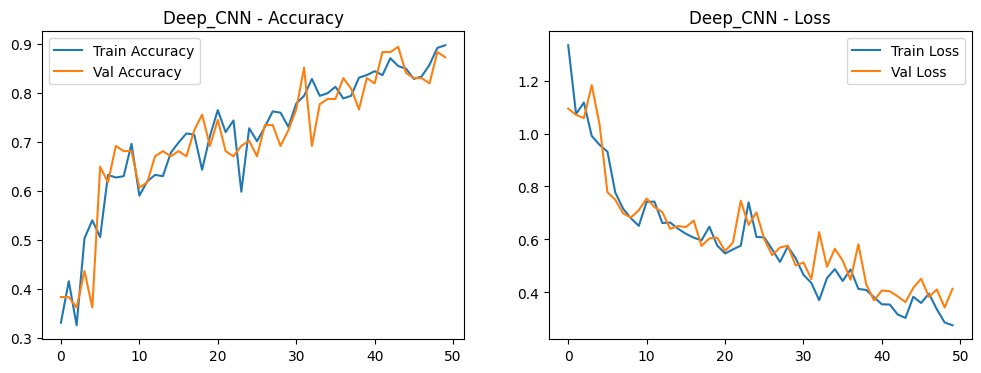

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step


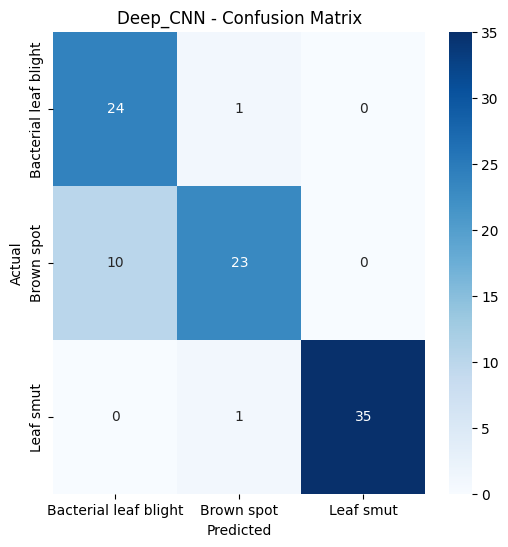

Deep_CNN - Classification Report
                       precision    recall  f1-score   support

Bacterial leaf blight       0.71      0.96      0.81        25
           Brown spot       0.92      0.70      0.79        33
            Leaf smut       1.00      0.97      0.99        36

             accuracy                           0.87        94
            macro avg       0.88      0.88      0.86        94
         weighted avg       0.89      0.87      0.87        94

Epoch 1/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 489ms/step - accuracy: 0.5355 - loss: 1.0913 - val_accuracy: 0.8511 - val_loss: 0.4772
Epoch 2/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 381ms/step - accuracy: 0.8025 - loss: 0.4526 - val_accuracy: 0.9043 - val_loss: 0.3124
Epoch 3/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 388ms/step - accuracy: 0.8924 - loss: 0.2976 - val_accuracy: 0.9362 - val_loss: 0.2661
Epoch 4/50
12/12 ━━━━━━━━━━━━━━━━━━━━ 5s 386ms/step - accuracy: 0.9397 - loss: 0.2073 - val_accuracy: 0.9362 - val_loss: 0.2543
Epoch 5/50


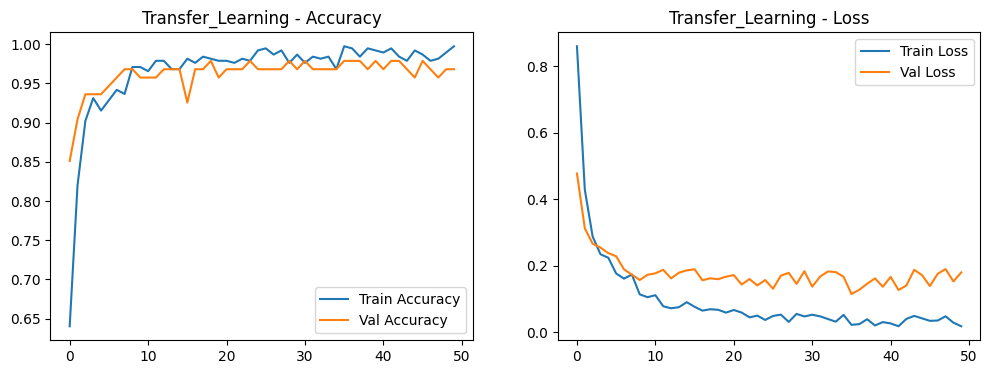

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 982ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 304ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 981ms/step


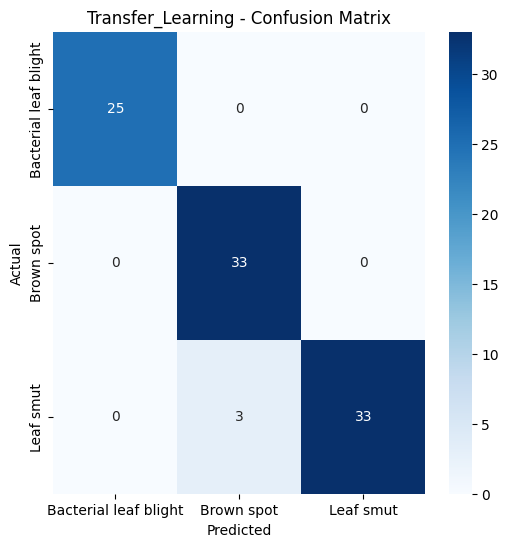

Transfer_Learning - Classification Report
                       precision    recall  f1-score   support

Bacterial leaf blight       1.00      1.00      1.00        25
           Brown spot       0.92      1.00      0.96        33
            Leaf smut       1.00      0.92      0.96        36

             accuracy                           0.97        94
            macro avg       0.97      0.97      0.97        94
         weighted avg       0.97      0.97      0.97        94



In [ ]:
train_and_evaluate(deep_cnn, "Deep_CNN")
train_and_evaluate(transfer_model, "Transfer_Learning")


In [ ]:
def load_model(model_path):
    return keras.models.load_model(model_path)


In [ ]:
def load_image(img_path):
    img = image.load_img(img_path, target_size=img_size)
    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)
    return img, img_array


In [20]:
def predict_external_image(img_path, model_path, class_names):
    model = load_model(model_path)
    img, img_array = load_image(img_path)
    pred = model.predict(img_array)
    class_index = np.argmax(pred)
    class_label = class_names[class_index]
    
    plt.imshow(img)
    plt.title(f"Predicted: {class_label}")
    plt.axis("off")
    plt.show()
    
    print(f"Predicted Class: {class_label}")


In [43]:
import tkinter as tk
from tkinter import filedialog, messagebox
from PIL import Image, ImageTk
import numpy as np
import tensorflow as tf
import cv2

class RiceLeafDiseaseClassifier:
    def __init__(self, root):
        self.root = root
        self.root.title("Rice Leaf Disease Classifier")
        self.root.geometry("800x600")
  
        self.deep_cnn_model_path = "Deep_CNN_model.h5"
        self.transfer_model_path = "Transfer_Learning_model.h5"

        self.deep_cnn_model = tf.keras.models.load_model(self.deep_cnn_model_path)
        self.transfer_model = tf.keras.models.load_model(self.transfer_model_path)

        self.class_names = [
            'Bacterial Leaf Blight', 
            'Brown Spot', 
            'Leaf Smut'
        ]

        self.create_widgets()

    def create_widgets(self):
        self.image_frame = tk.Frame(self.root, width=400, height=400)
        self.image_frame.pack(pady=10)

        self.image_label = tk.Label(self.image_frame, text="No Image Selected")
        self.image_label.pack(expand=True)

        self.button_frame = tk.Frame(self.root)
        self.button_frame.pack(pady=10)

        self.select_button = tk.Button(
            self.button_frame, 
            text="Select Image", 
            command=self.select_image
        )
        self.select_button.pack(side=tk.LEFT, padx=10)

        self.classify_button = tk.Button(
            self.button_frame, 
            text="Classify", 
            command=self.classify_image,
            state=tk.DISABLED
        )
        self.classify_button.pack(side=tk.LEFT, padx=10)

        self.results_frame = tk.Frame(self.root)
        self.results_frame.pack(pady=10)

        self.transfer_label = tk.Label(
            self.results_frame, 
            text="Transfer Learning Result: ",
            font=('Arial', 12)
        )
        self.transfer_label.pack()

        self.deep_cnn_label = tk.Label(
            self.results_frame, 
            text="Deep CNN Result: ",
            font=('Arial', 12)
        )
        self.deep_cnn_label.pack()

        self.current_image_path = None

    def select_image(self):
        self.current_image_path = filedialog.askopenfilename(
            title="Select Rice Leaf Image",
            filetypes=[
                ("Image files", "*.jpg *.jpeg *.png *.bmp *.gif"),
                ("All files", "*.*")
            ]
        )

        if self.current_image_path:
            image = Image.open(self.current_image_path)
            image.thumbnail((400, 400)) 
            photo = ImageTk.PhotoImage(image)
            
            self.image_label.config(image=photo)
            self.image_label.image = photo  # Keep a reference
            
            # Enable classify button
            self.classify_button.config(state=tk.NORMAL)

    def preprocess_image(self, image_path):
    # Read the image
        img = cv2.imread(image_path)
    
    # Convert BGR to RGB (if your model expects RGB)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    # Resize image to match model's expected input size
    # The error suggests the model expects (None, 256, 256, 3)
        img = cv2.resize(img, (256, 256))
    
    # Normalize pixel values
        img = img / 255.0
    
    # Expand dimensions to create batch dimension
        img = np.expand_dims(img, axis=0)
    
        return img

    def predict_external_image(self, image_path, model, class_names):
        # Preprocess the image
        processed_img = self.preprocess_image(image_path)
        
        # Make prediction
        predictions = model.predict(processed_img)
        predicted_class_index = np.argmax(predictions[0])
        confidence = predictions[0][predicted_class_index] * 100
        
        # Get class name
        predicted_class = class_names[predicted_class_index]
        
        return f"{predicted_class} (Confidence: {confidence:.2f}%)"

    def classify_image(self):
        if not self.current_image_path:
            messagebox.showerror("Error", "Please select an image first")
            return

        try:
            # Predict using Transfer Learning Model
            transfer_result = self.predict_external_image(
                self.current_image_path, 
                self.transfer_model, 
                self.class_names
            )
            
            # Predict using Deep CNN Model
            deep_cnn_result = self.predict_external_image(
                self.current_image_path, 
                self.deep_cnn_model, 
                self.class_names
            )

            # Update results labels
            self.transfer_label.config(
                text=f"Transfer Learning Result: {transfer_result}"
            )
            self.deep_cnn_label.config(
                text=f"Deep CNN Result: {deep_cnn_result}"
            )

        except Exception as e:
            messagebox.showerror("Prediction Error", str(e))

def main():
    root = tk.Tk()
    app = RiceLeafDiseaseClassifier(root)
    root.mainloop()

if __name__ == "__main__":
    main()

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step
